In [116]:
import sys, os

while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# load data
df = pd.read_csv('data/egx/ABUK.csv')

# استخدم عمود السعر (غير الاسم لو مختلف)
prices = df['close'].values.astype('float32')

# نحوله ل time series
series = prices

In [117]:
X = series[:-1].reshape(-1, 1).astype('float32')
y = series[1:].astype('float32')

# split زمني (مهم جدًا)
split = int(len(X) * 0.7)

Xtr, ytr = torch.tensor(X[:split]), torch.tensor(y[:split])
Xte, yte = torch.tensor(X[split:]), torch.tensor(y[split:])

In [118]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = MLP()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

In [119]:
train_hist, test_hist = [], []

for epoch in range(300):
    opt.zero_grad()
    
    loss = nn.functional.mse_loss(model(Xtr), ytr)
    loss.backward()
    opt.step()
    
    train_hist.append(loss.item())
    test_hist.append(
        nn.functional.mse_loss(model(Xte), yte).item()
    )

In [120]:
# baseline: predict tomorrow = today
persistence_loss = nn.functional.mse_loss(
    Xte.squeeze(-1), yte
).item()

print(f'final train loss: {train_hist[-1]:.5f}')
print(f'final test loss:  {test_hist[-1]:.5f}')
print(f'"just predict no change" loss: {persistence_loss:.5f}')

final train loss: 0.19919
final test loss:  3.48858
"just predict no change" loss: 3.37607


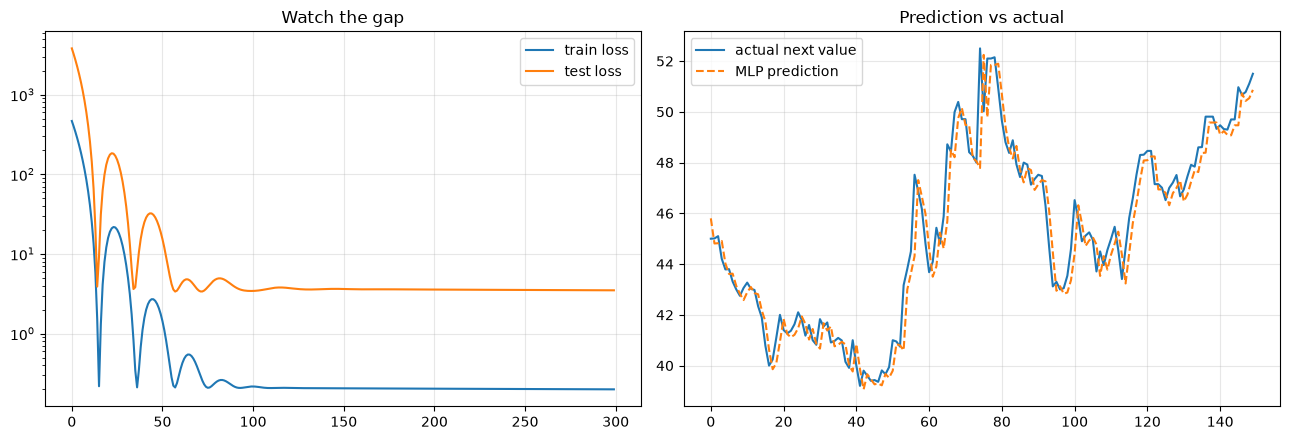

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# loss curves
axes[0].plot(train_hist, label='train loss')
axes[0].plot(test_hist, label='test loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=.3)
axes[0].set_title('Watch the gap')

# predictions
with torch.no_grad():
    pred_test = model(Xte).numpy()

show_n = 150

axes[1].plot(y[split:split+show_n], label='actual next value', linewidth=1.5)
axes[1].plot(pred_test[:show_n], label='MLP prediction', linewidth=1.5, linestyle='--')

axes[1].legend()
axes[1].grid(alpha=.3)
axes[1].set_title('Prediction vs actual')

plt.tight_layout()
plt.show()

In [122]:
from sklearn.metrics import r2_score

# predictions
with torch.no_grad():
    train_pred = model(Xtr).numpy()
    test_pred = model(Xte).numpy()

# R2
r2_train = r2_score(ytr.numpy(), train_pred)
r2_test = r2_score(yte.numpy(), test_pred)

print(f"R2 train: {r2_train:.4f}")
print(f"R2 test:  {r2_test:.4f}")

R2 train: 0.9967
R2 test:  0.9826


R2 Score: 0.983174204826355


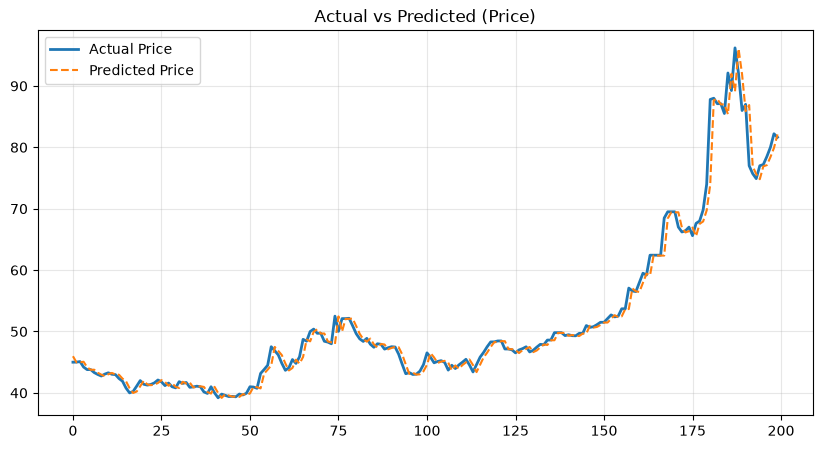

In [124]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# نفترض إن عندك X = price[:-1] و y = price[1:] أو أي تجهيز عملته

# --- Split (time series style) ---
split = int(len(X) * 0.7)

Xtr = torch.tensor(X[:split])
ytr = torch.tensor(y[:split])

Xte = torch.tensor(X[split:])
yte = torch.tensor(y[split:])

# --- Model جديد بنفس ال architecture ---
model3 = MLP()
opt3 = torch.optim.Adam(model3.parameters(), lr=0.01)

train_hist3, test_hist3 = [], []

# --- Training loop ---
for epoch in range(300):
    opt3.zero_grad()
    
    pred_tr = model3(Xtr)
    loss = nn.functional.mse_loss(pred_tr, ytr)
    
    loss.backward()
    opt3.step()
    
    train_hist3.append(loss.item())
    
    with torch.no_grad():
        pred_te = model3(Xte)
        test_loss = nn.functional.mse_loss(pred_te, yte).item()
        test_hist3.append(test_loss)

# --- Predictions ---
with torch.no_grad():
    y_pred = model3(Xte).numpy()

y_true = yte.numpy()

# --- R2 Score ---
r2 = r2_score(y_true, y_pred)
print("R2 Score:", r2)

# --- Plot ---
plt.figure(figsize=(10,5))

plt.plot(y_true[:200], label='Actual Price', linewidth=2)
plt.plot(y_pred[:200], label='Predicted Price', linestyle='--')

plt.legend()
plt.grid(alpha=0.3)
plt.title("Actual vs Predicted (Price)")

plt.show()